# Chebyshev Gradient Demonstration

This notebook demonstrates how backpropagation works through the hard `max` operator in the 2-objective Chebyshev scalarization used in this repo.

We use the form:

$$d_i = \max(l_i - z_i, 0)$$
$$g_i = w_i d_i$$
$$L = \max(g_r, g_f) + \rho (g_r + g_f)$$

where:
- $l_r$: retain loss
- $l_f$: forget loss
- $z_r, z_f$: reference values
- $w_r, w_f$: task weights
- $\rho$: augmentation coefficient


In [1]:
import torch

torch.set_printoptions(precision=6, sci_mode=False)


In [2]:
def chebyshev_loss(l_r, l_f, w_r=1.0, w_f=1.0, z_r=0.0, z_f=0.0, rho=1e-3):
    d_r = torch.clamp(l_r - z_r, min=0.0)
    d_f = torch.clamp(l_f - z_f, min=0.0)

    g_r = w_r * d_r
    g_f = w_f * d_f

    g = torch.stack([g_r, g_f])
    max_term, active_idx = torch.max(g, dim=0)
    augmentation = rho * g.sum()
    loss = max_term + augmentation

    return {
        "d_r": d_r,
        "d_f": d_f,
        "g_r": g_r,
        "g_f": g_f,
        "active_idx": active_idx,
        "max_term": max_term,
        "augmentation": augmentation,
        "loss": loss,
    }


## Case 1: retain objective is the active max

Here $g_r > g_f$, so the gradient from the hard max should flow mainly through the retain branch.


In [3]:
l_r = torch.tensor(0.8, requires_grad=True)
l_f = torch.tensor(0.3, requires_grad=True)
result = chebyshev_loss(l_r, l_f, w_r=1.0, w_f=1.0, z_r=0.0, z_f=0.0, rho=1e-3)
result["loss"].backward()

print("active_idx =", int(result["active_idx"]))
print("g_r =", float(result["g_r"].detach()), "g_f =", float(result["g_f"].detach()))
print("max_term =", float(result["max_term"].detach()))
print("augmentation =", float(result["augmentation"].detach()))
print("dL/dl_r =", float(l_r.grad), "dL/dl_f =", float(l_f.grad))


active_idx = 0
g_r = 0.800000011920929 g_f = 0.30000001192092896
max_term = 0.800000011920929
augmentation = 0.0011000001104548573
dL/dl_r = 1.0010000467300415 dL/dl_f = 0.0010000000474974513


Expected behavior:

$$\frac{\partial L}{\partial l_r} = (1+\rho) w_r, \quad \frac{\partial L}{\partial l_f} = \rho w_f$$

because the hard max selects the retain branch and the augmentation term contributes to both.


## Case 2: forget objective is the active max

Now $g_f > g_r$, so the dominant gradient should move to the forget branch.


In [4]:
l_r = torch.tensor(0.2, requires_grad=True)
l_f = torch.tensor(0.9, requires_grad=True)
result = chebyshev_loss(l_r, l_f, w_r=1.0, w_f=1.0, z_r=0.0, z_f=0.0, rho=1e-3)
result["loss"].backward()

print("active_idx =", int(result["active_idx"]))
print("g_r =", float(result["g_r"].detach()), "g_f =", float(result["g_f"].detach()))
print("dL/dl_r =", float(l_r.grad), "dL/dl_f =", float(l_f.grad))


active_idx = 1
g_r = 0.20000000298023224 g_f = 0.8999999761581421
dL/dl_r = 0.0010000000474974513 dL/dl_f = 1.0010000467300415


Expected behavior:

$$\frac{\partial L}{\partial l_r} = \rho w_r, \quad \frac{\partial L}{\partial l_f} = (1+\rho) w_f$$


## Case 3: clamp shuts off gradients below the reference point

Because the implementation uses `torch.clamp(loss - reference_point, min=0.0)`, a loss below its reference value does not contribute gradient.


In [5]:
l_r = torch.tensor(0.2, requires_grad=True)
l_f = torch.tensor(0.9, requires_grad=True)
result = chebyshev_loss(l_r, l_f, w_r=1.0, w_f=1.0, z_r=0.5, z_f=0.0, rho=1e-3)
result["loss"].backward()

print("d_r =", float(result["d_r"].detach()), "d_f =", float(result["d_f"].detach()))
print("dL/dl_r =", float(l_r.grad), "dL/dl_f =", float(l_f.grad))


d_r = 0.0 d_f = 0.8999999761581421
dL/dl_r = 0.0 dL/dl_f = 1.0010000467300415


Here $l_r < z_r$, so the retain branch is inactive and its gradient becomes zero.


## Case 4: changing weights changes which task dominates

The hard max depends on the weighted deviations, not the raw losses.


In [6]:
l_r = torch.tensor(0.4, requires_grad=True)
l_f = torch.tensor(0.35, requires_grad=True)
result = chebyshev_loss(l_r, l_f, w_r=1.0, w_f=2.0, z_r=0.0, z_f=0.0, rho=1e-3)
result["loss"].backward()

print("g_r =", float(result["g_r"].detach()), "g_f =", float(result["g_f"].detach()))
print("active_idx =", int(result["active_idx"]))
print("dL/dl_r =", float(l_r.grad), "dL/dl_f =", float(l_f.grad))


g_r = 0.4000000059604645 g_f = 0.699999988079071
active_idx = 1
dL/dl_r = 0.0010000000474974513 dL/dl_f = 2.002000093460083


Even though $l_r > l_f$, the forget branch can dominate if its weight is larger.


## Summary

For the current augmented Chebyshev implementation in this repo:

- The `max` term sends gradient only through the active worst weighted deviation.
- The augmentation term sends gradient through all active objectives.
- The clamp creates an active-set effect around the reference point.
- This is why hard Tchebycheff can optimize but may switch abruptly between tasks.


## Visualizing Hard Chebyshev vs Smooth STCH

Yes. A very helpful way to understand the difference is to visualize the scalarized objective over a 2D grid of retain and forget losses.

- Hard Chebyshev uses a sharp `max` ridge.
- Smooth STCH uses `logsumexp`, which softens that ridge and spreads gradient across both objectives.


In [7]:
import numpy as np
import matplotlib.pyplot as plt


In [8]:
def hard_chebyshev_surface(lr, lf, w_r=1.0, w_f=1.0, z_r=0.0, z_f=0.0, rho=1e-3):
    d_r = np.maximum(lr - z_r, 0.0)
    d_f = np.maximum(lf - z_f, 0.0)
    g_r = w_r * d_r
    g_f = w_f * d_f
    return np.maximum(g_r, g_f) + rho * (g_r + g_f)

def stch_surface(lr, lf, w_r=1.0, w_f=1.0, z_r=0.0, z_f=0.0, rho=1e-3, tau=0.1):
    d_r = np.maximum(lr - z_r, 0.0)
    d_f = np.maximum(lf - z_f, 0.0)
    g_r = w_r * d_r
    g_f = w_f * d_f
    g = np.stack([g_r, g_f], axis=0)
    smooth_max = tau * np.log(np.exp(g / tau).sum(axis=0))
    return smooth_max + rho * (g_r + g_f)


In [9]:
lr_vals = np.linspace(0.0, 1.2, 200)
lf_vals = np.linspace(0.0, 1.2, 200)
LR, LF = np.meshgrid(lr_vals, lf_vals)

hard = hard_chebyshev_surface(LR, LF, rho=1e-3)
smooth = stch_surface(LR, LF, rho=1e-3, tau=0.12)


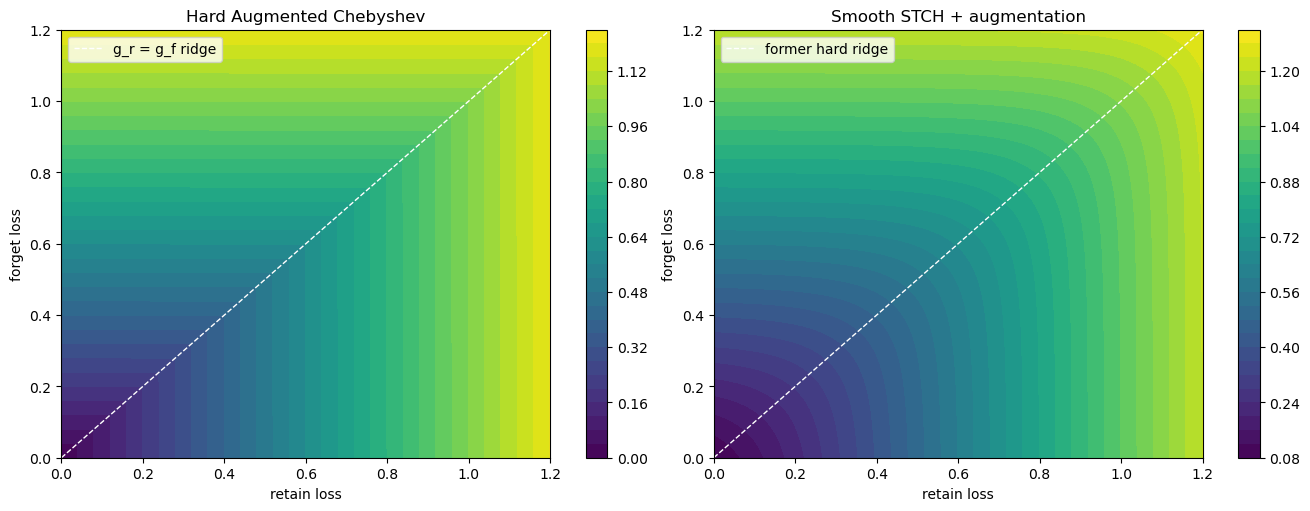

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

im0 = axes[0].contourf(LR, LF, hard, levels=30, cmap="viridis")
axes[0].plot([0, 1.2], [0, 1.2], "w--", linewidth=1, label="g_r = g_f ridge")
axes[0].set_title("Hard Augmented Chebyshev")
axes[0].set_xlabel("retain loss")
axes[0].set_ylabel("forget loss")
axes[0].legend(loc="upper left")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(LR, LF, smooth, levels=30, cmap="viridis")
axes[1].plot([0, 1.2], [0, 1.2], "w--", linewidth=1, label="former hard ridge")
axes[1].set_title("Smooth STCH + augmentation")
axes[1].set_xlabel("retain loss")
axes[1].set_ylabel("forget loss")
axes[1].legend(loc="upper left")
fig.colorbar(im1, ax=axes[1])

plt.show()


The main geometric difference is that the hard Chebyshev objective has a sharp switching boundary, while STCH rounds that boundary into a smooth transition region.


In [11]:
def torch_hard_loss(l_r, l_f, rho=1e-3):
    g = torch.stack([torch.clamp(l_r, min=0.0), torch.clamp(l_f, min=0.0)])
    return torch.max(g) + rho * g.sum()

def torch_stch_loss(l_r, l_f, rho=1e-3, tau=0.12):
    g = torch.stack([torch.clamp(l_r, min=0.0), torch.clamp(l_f, min=0.0)])
    return tau * torch.logsumexp(g / tau, dim=0) + rho * g.sum()

def grad_field(loss_fn, x_vals, y_vals):
    U = np.zeros((len(y_vals), len(x_vals)))
    V = np.zeros((len(y_vals), len(x_vals)))
    for iy, y in enumerate(y_vals):
        for ix, x in enumerate(x_vals):
            l_r = torch.tensor(float(x), requires_grad=True)
            l_f = torch.tensor(float(y), requires_grad=True)
            loss = loss_fn(l_r, l_f)
            loss.backward()
            U[iy, ix] = l_r.grad.item()
            V[iy, ix] = l_f.grad.item()
    return U, V


In [12]:
x_small = np.linspace(0.0, 1.0, 13)
y_small = np.linspace(0.0, 1.0, 13)
XS, YS = np.meshgrid(x_small, y_small)

U_h, V_h = grad_field(torch_hard_loss, x_small, y_small)
U_s, V_s = grad_field(torch_stch_loss, x_small, y_small)


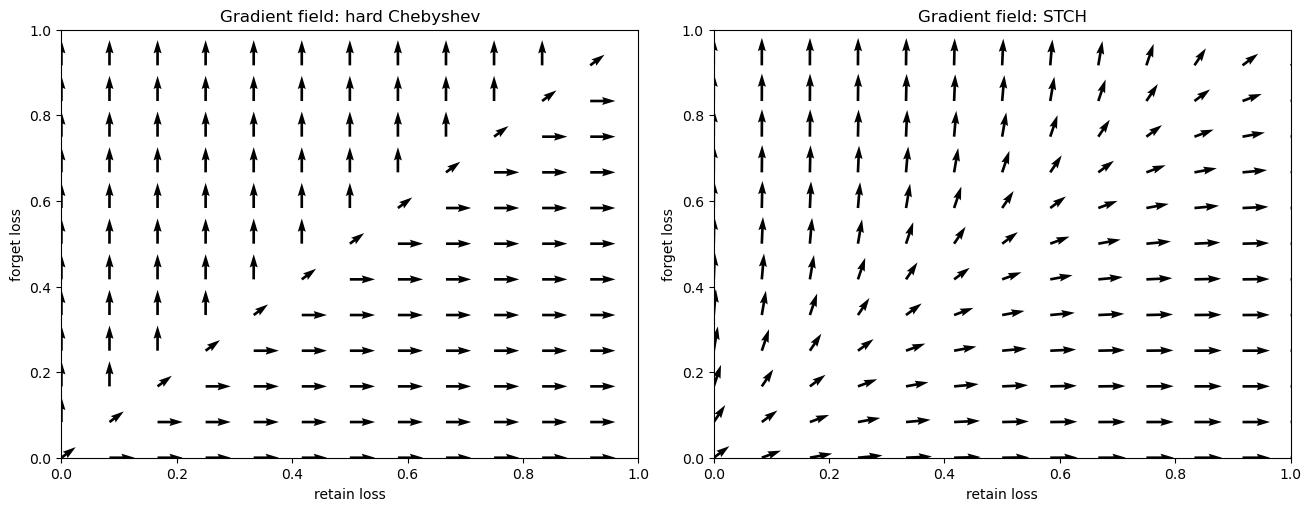

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].quiver(XS, YS, U_h, V_h, angles="xy")
axes[0].set_title("Gradient field: hard Chebyshev")
axes[0].set_xlabel("retain loss")
axes[0].set_ylabel("forget loss")
axes[0].set_xlim(0, 1.0)
axes[0].set_ylim(0, 1.0)

axes[1].quiver(XS, YS, U_s, V_s, angles="xy")
axes[1].set_title("Gradient field: STCH")
axes[1].set_xlabel("retain loss")
axes[1].set_ylabel("forget loss")
axes[1].set_xlim(0, 1.0)
axes[1].set_ylim(0, 1.0)

plt.show()


These quiver plots make the optimization difference visible:

- Hard Chebyshev sends most gradient through one objective at a time, with abrupt switching near the ridge.
- STCH spreads gradient more smoothly across both objectives, especially near the transition boundary.


/tmp/ipykernel_2983487/1041476145.py:44: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  traj_lambda = torch.tensor(traj_lambda)


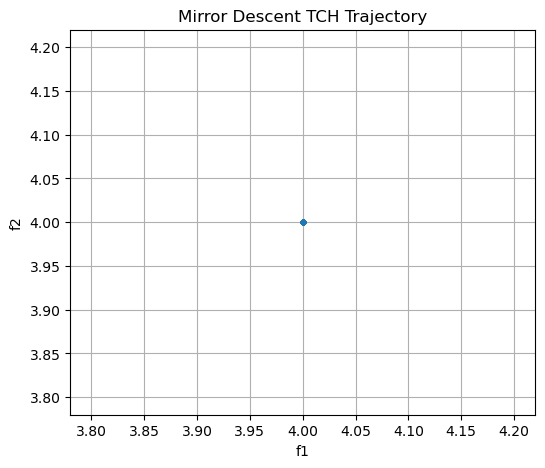

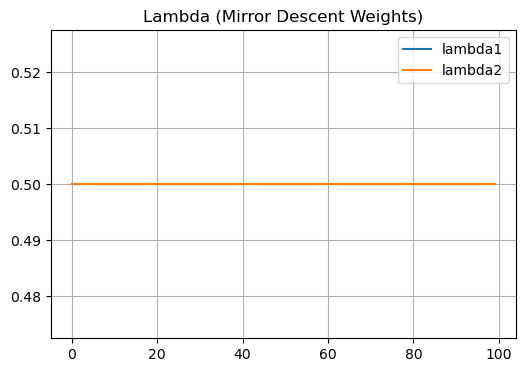

In [ ]:
import torch
import matplotlib.pyplot as plt

# ---- setup ----
T = 100
lr = 0.05
tau = 0.1

theta = torch.tensor([0.0], requires_grad=True)

traj_f1 = []
traj_f2 = []
traj_lambda = []

for t in range(T):
# objectives
f1 = (theta - 2)**2
f2 = (theta + 2)**2

losses = torch.stack([f1, f2]).squeeze()

# Chebyshev STCH weights (mirror descent interpretation)
g = losses
weights = torch.softmax(g / tau, dim=0)

# store
traj_f1.append(f1.item())
traj_f2.append(f2.item())
traj_lambda.append(weights.detach().numpy())

# gradient
grad = torch.autograd.grad(
    (weights[0]*f1 + weights[1]*f2), theta
)[0]

# update
with torch.no_grad():
    theta -= lr * grad
    theta.requires_grad_()

# ---- convert ----
traj_f1 = torch.tensor(traj_f1)
traj_f2 = torch.tensor(traj_f2)
traj_lambda = torch.tensor(traj_lambda)

# ---- plot Pareto trajectory ----
plt.figure(figsize=(6,5))
plt.plot(traj_f1, traj_f2, '-o', markersize=3)
plt.xlabel("f1")
plt.ylabel("f2")
plt.title("Mirror Descent TCH Trajectory")
plt.grid()
plt.show()

# ---- plot lambda evolution ----
plt.figure(figsize=(6,4))
plt.plot(traj_lambda[:,0], label="lambda1")
plt.plot(traj_lambda[:,1], label="lambda2")
plt.legend()
plt.title("Lambda (Mirror Descent Weights)")
plt.grid()
plt.show()